# Previsão de Quantidade de Passageiros


## 1. Objetivo do Notebook
Este notebook teve como objetivo desenvolver e comparar modelos preditivos para a demanda de passageiros de ônibus (**`Total Passageiros`**). Exploramos duas abordagens distintas:
1.  **Regressão Clássica (RandomForest)**: Focada em prever a demanda de cada viagem individual com base em características tabulares (linha, hora, local).
2.  **Séries Temporais (RNN, ARIMA, SARIMA)**: Focadas em prever a demanda agregada da rede (total de passageiros por hora) ao longo do tempo, capturando tendências e sazonalidades.

## 2. Preparação dos Dados
*   **Dataset Original**: Registros de 2009 a 2018, porém com grandes lacunas temporais.
*   **Filtragem**: Para os modelos de série temporal (que exigem continuidade), filtramos o dataset para utilizar apenas o período denso e contínuo de **2018 (Fevereiro-Março)**.
*   **Agregação**: Os modelos de série temporal foram treinados com dados agregados por **Hora** (soma de passageiros), enquanto o RandomForest utilizou os registros individuais originais.

> **Nota de Pré-processamento**: Foi identificado que o dataset original possui registros esparsos entre 2009 e 2017. Para garantir uma modelagem de séries temporais consistente (sem longos períodos de interpolação artificial), os modelos ARIMA, SARIMA e RNN foram treinados e avaliados focando no período contínuo de dados de **2018**.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

plt.style.use('ggplot')

## 1. Carregamento dos Dados
Vamos carregar o arquivo CSV, ajustando o separador para ponto e vírgula (`;`) e corrigindo a codificação.

In [ ]:
path = Path("dataset/movimentacao_sobe_desce_29-11-2018-004.csv")

try:
    df = pd.read_csv(path, sep=';', encoding='latin1')
    print("Dados carregados com sucesso!")
except FileNotFoundError:
    print(f"Arquivo não encontrado em: {path}. Verifique o caminho.")

df.head()

Dados carregados com sucesso!


,Linha/SubLinha,Servico,Consorcio,Data Pesquisa,Dia Semana,Rota,Hora Viagem,Sequencia do PED,Endereco do PED,Embarque,Desembarque,Saldo,Total Passageiros,Latitude,Longitude
0,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,1,RUA DAS ALMAS 122 ...,9,0,9,41,"-19,833061","-43,883134"
1,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,2,RUA DAS ALMAS 96 ...,3,0,12,41,"-19,830729","-43,884487"
2,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,3,RUA DAS ALMAS 22 ...,4,0,16,41,"-19,830751","-43,886302"
3,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,4,RUA ANJO AZUL 69 ...,3,0,19,41,"-19,82981","-43,888611"
4,815/01,ALIMENTADORA,CONSORCIO BHLESTE,05/12/2015,Sabado,Pc1->Pc2,06:00,5,RUA ANJO AZUL 37 ...,2,0,21,41,"-19,830045","-43,889373"


## 2. Limpeza e Pré-processamento
- Remover espaços em branco dos nomes das colunas.
- Converter colunas numéricas (Latitude, Longitude) que estão como strings com vírgula.
- Ajustar tipos de dados de data e hora.

In [ ]:
df.columns = df.columns.str.strip()

cols_float = ['Latitude', 'Longitude']
for col in cols_float:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116094 entries, 0 to 116093
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Linha/SubLinha     116094 non-null  object 
 1   Servico            116094 non-null  object 
 2   Consorcio          116094 non-null  object 
 3   Data Pesquisa      116094 non-null  object 
 4   Dia Semana         116094 non-null  object 
 5   Rota               116094 non-null  object 
 6   Hora Viagem        116094 non-null  object 
 7   Sequencia do PED   116094 non-null  int64  
 8   Endereco do PED    116094 non-null  object 
 9   Embarque           116094 non-null  int64  
 10  Desembarque        116094 non-null  int64  
 11  Saldo              116094 non-null  int64  
 12  Total Passageiros  116094 non-null  int64  
 13  Latitude           116094 non-null  float64
 14  Longitude          116094 non-null  float64
dtypes: float64(2), int64(5), object(8)
memory usage: 13

## 3. Engenharia de Features
Vamos extrair informações úteis de horário e preparar as variáveis categóricas.

In [ ]:

df['Hora'] = pd.to_datetime(df['Hora Viagem'], format='%H:%M:%S', errors='coerce').dt.hour
df['Hora'] = df['Hora'].fillna(0).astype(int)  

le_linha = LabelEncoder()
df['Linha_Encoded'] = le_linha.fit_transform(df['Linha/SubLinha'].astype(str))

le_sem = LabelEncoder()
df['Semana_Encoded'] = le_sem.fit_transform(df['Dia Semana'].astype(str))

features = ['Linha_Encoded', 'Semana_Encoded', 'Hora', 'Sequencia do PED', 'Latitude', 'Longitude']
target = 'Total Passageiros'

print("Features selecionadas:", features)
print("\nTipos das features:")
print(df[features].dtypes)
print("\nPrimeiras linhas do X:")
print(df[features].head())


Features selecionadas: ['Linha_Encoded', 'Semana_Encoded', 'Hora', 'Sequencia do PED', 'Latitude', 'Longitude']

Tipos das features:
Linha_Encoded         int64
Semana_Encoded        int64
Hora                  int64
Sequencia do PED      int64
Latitude            float64
Longitude           float64
dtype: object

Primeiras linhas do X:
   Linha_Encoded  Semana_Encoded  Hora  Sequencia do PED   Latitude  Longitude
0              0               3     0                 1 -19.833061 -43.883134
1              0               3     0                 2 -19.830729 -43.884487
2              0               3     0                 3 -19.830751 -43.886302
3              0               3     0                 4 -19.829810 -43.888611
4              0               3     0                 5 -19.830045 -43.889373


## 4. Análise Exploratória Rápida

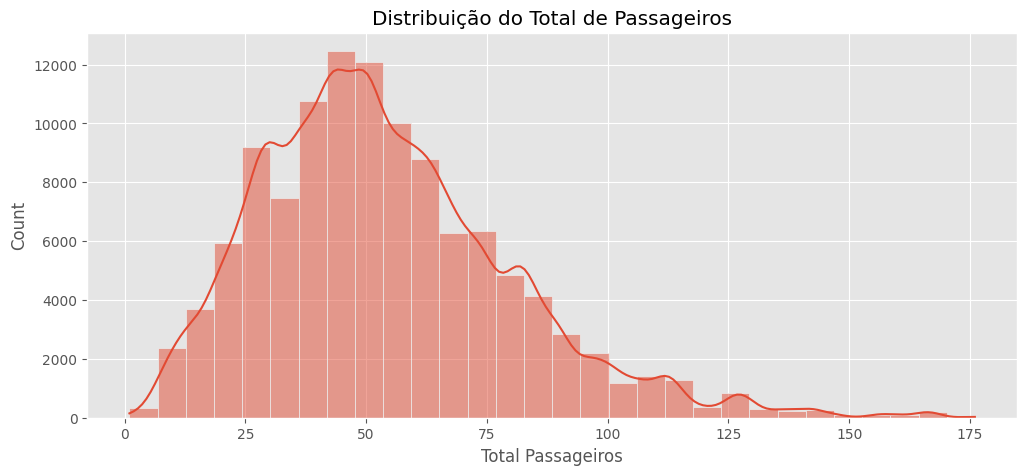

In [5]:
plt.figure(figsize=(12, 5))
sns.histplot(df[target], bins=30, kde=True)
plt.title('Distribuição do Total de Passageiros')
plt.show()

#plt.figure(figsize=(12, 5))
#sns.boxplot(x='Hora', y=target, data=df)
#plt.title('Passageiros por Hora do Dia')
#plt.show()

## 5. Modelagem Preditiva
Vamos dividir os dados em treino e teste e treinar um modelo RandomForestRegressor.

In [ ]:
X = df[features]
y = df[target]

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instanciar e Treinar Modelo
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)
print("Previsões", y_pred)

# Avaliação
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Previsões [40.62865166 68.89116034 68.36416655 ... 40.14123768 70.34474149
 56.72773321]
MAE: 14.95
RMSE: 20.10
R2 Score: 0.41


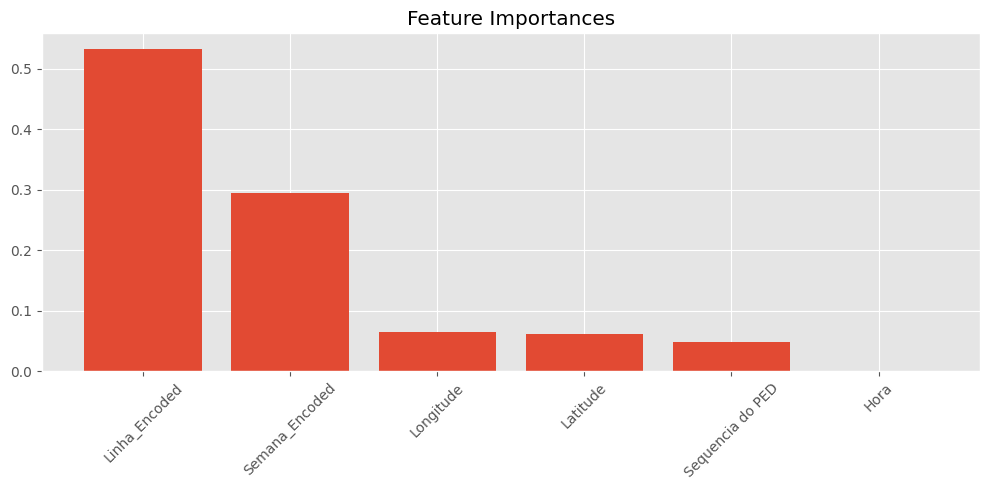

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## 6. Visualização dos Resultados
Comparando Real vs Previsto.

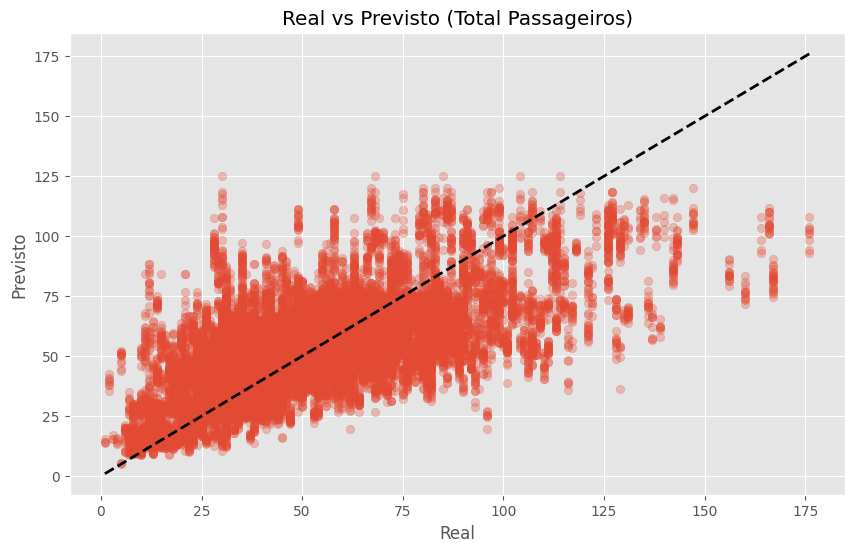

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.title('Real vs Previsto (Total Passageiros)')
plt.show()

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_length):
        self.series = torch.tensor(series, dtype=torch.float32)
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

serie_temporal = df['Total Passageiros'].values

n = len(serie_temporal)
train_end = int(n * 0.7)
valid_end = int(n * 0.9)

rail_train = serie_temporal[:train_end]
rail_valid = serie_temporal[train_end:valid_end]
rail_test = serie_temporal[valid_end:]

window_length = 56
batch_size = 32

train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=batch_size)

test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=batch_size)

print(f"Tamanhos dos conjuntos: Treino={len(train_set)}, Validação={len(valid_set)}, Teste={len(test_set)}")

Tamanhos dos conjuntos: Treino=81209, Validação=23163, Teste=11554


2026-01-27 16:45:03.504855: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Treinando SimpleRNN (CPU)...
Epoch 1/5


2026-01-27 16:45:06.934716: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-01-27 16:45:06.934739: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2026-01-27 16:45:06.934743: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-01-27 16:45:06.934745: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-01-27 16:45:06.934748: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: dario-ubuntu
2026-01-27 16:45:06.934749: I external/local_xla/xla/stream_executor/cuda/

2903/2903 ━━━━━━━━━━━━━━━━━━━━ 3s 739us/step - loss: 8.2291e-04
Epoch 2/5
2903/2903 ━━━━━━━━━━━━━━━━━━━━ 2s 595us/step - loss: 6.1281e-04
Epoch 3/5
2903/2903 ━━━━━━━━━━━━━━━━━━━━ 2s 601us/step - loss: 6.0866e-04
Epoch 4/5
2903/2903 ━━━━━━━━━━━━━━━━━━━━ 2s 608us/step - loss: 6.0831e-04
Epoch 5/5
2903/2903 ━━━━━━━━━━━━━━━━━━━━ 2s 608us/step - loss: 6.0215e-04
726/726 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step
------------------------------
Resultados SimpleRNN:
MAE: 1.57
RMSE: 3.98
R2 Score: 0.98


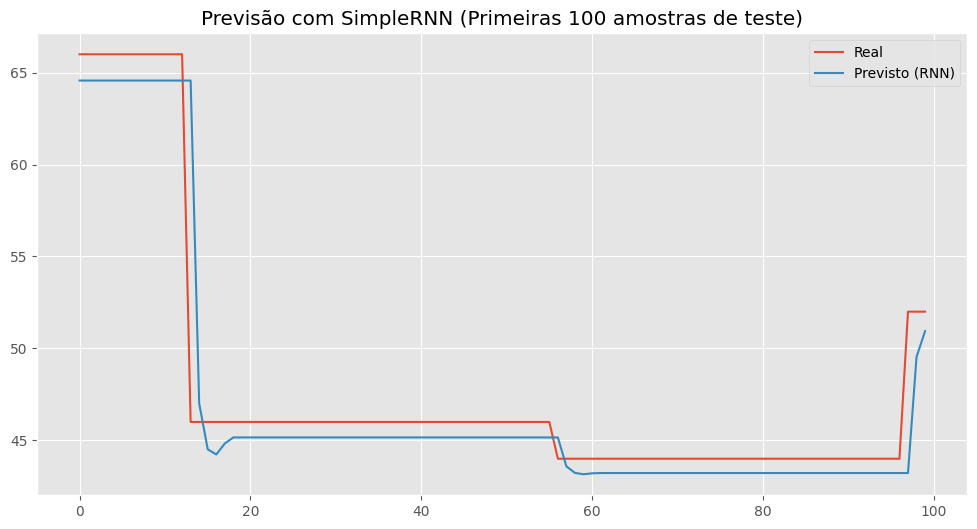

In [ ]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(df['Data Pesquisa'] + ' ' + df['Hora Viagem'], dayfirst=True)
df = df.sort_values('Datetime')

data_ts = df['Total Passageiros'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_ts)

def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 5
X_rnn, y_rnn = create_dataset(data_scaled, look_back)

X_rnn = np.reshape(X_rnn, (X_rnn.shape[0], 1, look_back))

train_size = int(len(X_rnn) * 0.8)
X_train_rnn, X_test_rnn = X_rnn[0:train_size], X_rnn[train_size:]
y_train_rnn, y_test_rnn = y_rnn[0:train_size], y_rnn[train_size:]

model_rnn = Sequential()
model_rnn.add(Input(shape=(1, look_back)))
model_rnn.add(SimpleRNN(50, activation='relu'))
model_rnn.add(Dense(1))
model_rnn.compile(loss='mean_squared_error', optimizer='adam')

print("Treinando SimpleRNN (CPU)...")
model_rnn.fit(X_train_rnn, y_train_rnn, epochs=5, batch_size=32, verbose=1)

test_predict = model_rnn.predict(X_test_rnn)

test_predict_real = scaler.inverse_transform(test_predict)
y_test_real = scaler.inverse_transform([y_test_rnn]).T

# Métricas
mae_rnn = mean_absolute_error(y_test_real, test_predict_real)
rmse_rnn = np.sqrt(mean_squared_error(y_test_real, test_predict_real))
r2_rnn = r2_score(y_test_real, test_predict_real)

print("-" * 30)
print("Resultados SimpleRNN:")
print(f"MAE: {mae_rnn:.2f}")
print(f"RMSE: {rmse_rnn:.2f}")
print(f"R2 Score: {r2_rnn:.2f}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_real[:100], label='Real')
plt.plot(test_predict_real[:100], label='Previsto (RNN)')
plt.legend()
plt.title('Previsão com SimpleRNN (Primeiras 100 amostras de teste)')
plt.show()



PREPARAÇÃO DA SÉRIE TEMPORAL (ARIMA/SARIMA) + MAPE
Dados filtrados para 2018: 11023 registros.
Série Temporal Criada. Amostras: 632

Analise de Estacionaridade: Série Original (Não Estacionária?)
ADF Statistic: -2.2424995820922224
p-value: 0.19118356699707117


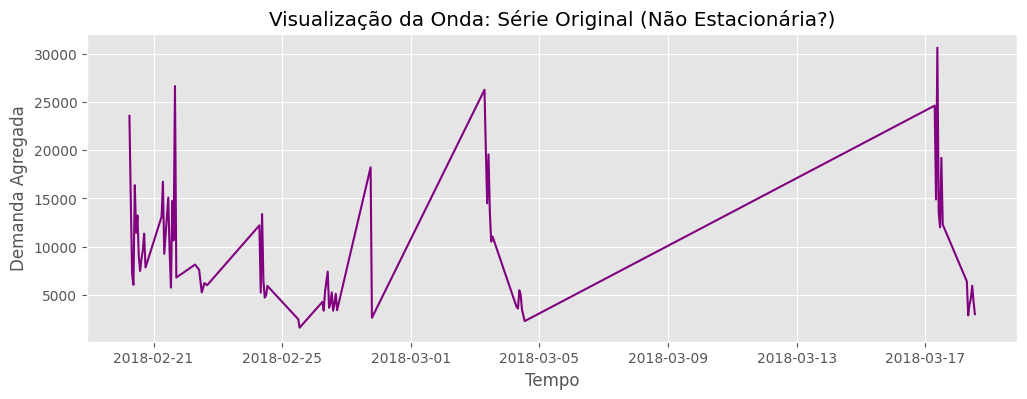

Série Original NÃO é estacionária. Aplicando diferenciação...

Analise de Estacionaridade: Série Diferenciada (Onda Estacionária)
ADF Statistic: -8.444148213313037
p-value: 1.73098065405714e-13


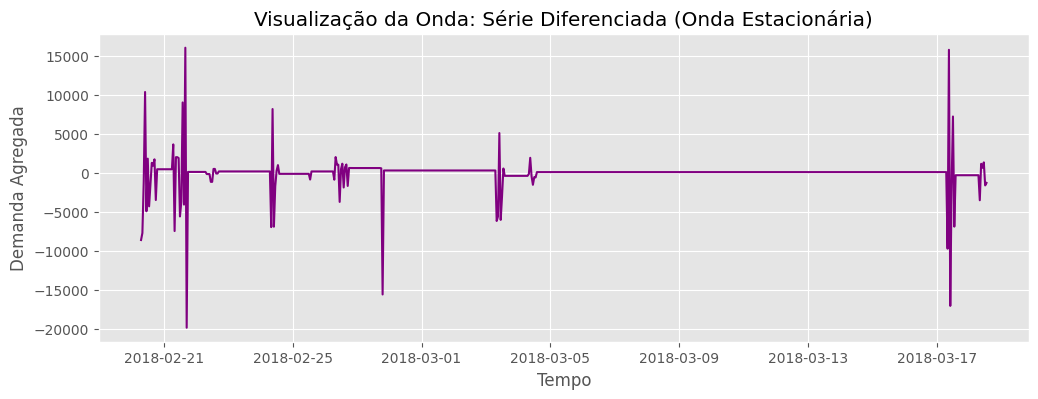

Série Diferenciada é estacionária.

------------------------------
Treinando Modelo ARIMA(5,1,0)...
ARIMA -> MAE: 4827.15, RMSE: 5830.82, MAPE: 44.52%, R2: -0.03

------------------------------
Treinando Modelo SARIMA(1,1,1)(1,1,0,24)...
SARIMA -> MAE: 3878.32, RMSE: 8284.28, MAPE: 58.35%, R2: -1.07


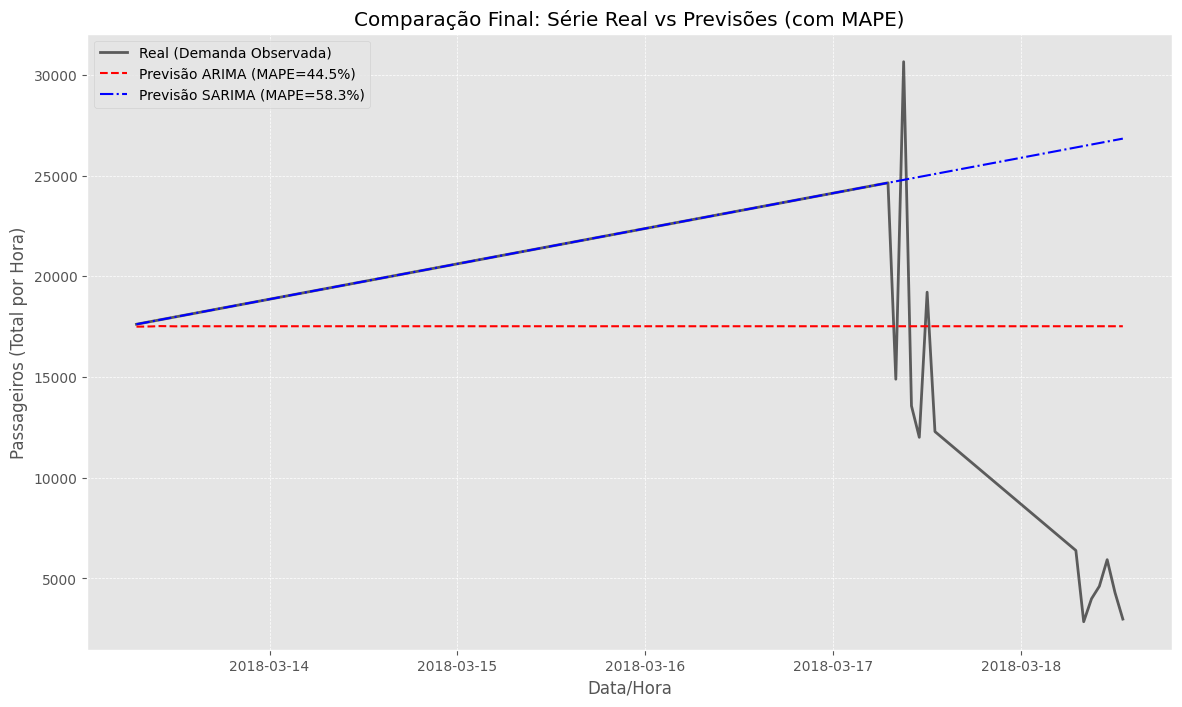

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

print("\n" + "="*50)
print("PREPARAÇÃO DA SÉRIE TEMPORAL (ARIMA/SARIMA) + MAPE")
print("="*50)

if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(df['Data Pesquisa'] + ' ' + df['Hora Viagem'], dayfirst=True)

# FILTRAGEM TEMPORAL: Focar em 2018 para evitar grandes buracos de anos anteriores que geram retas de interpolação
# O dataset tem dados esparsos de 2009 a 2018. Focaremos no período contínuo mais recente (Fev-Mar 2018).
df_filtered = df[df['Datetime'] >= '2018-02-01'].copy()
print(f"Dados filtrados para 2018: {len(df_filtered)} registros.")

ts_data = df_filtered.set_index('Datetime').resample('H')['Total Passageiros'].sum().fillna(0)
ts_data = ts_data.replace(0, np.nan).interpolate().fillna(0) 

print(f"Série Temporal Criada. Amostras: {len(ts_data)}")

train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]

# 2. Teste de Estacionaridade (ADF) e Visualização da Onda
def check_stationarity(timeseries, title):
    print(f'\nAnalise de Estacionaridade: {title}')
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    
    # Plot da Onda (Série)
    plt.figure(figsize=(12, 4))
    plt.plot(timeseries, color='purple')
    plt.title(f'Visualização da Onda: {title}')
    plt.xlabel('Tempo')
    plt.ylabel('Demanda Agregada')
    plt.grid(True)
    plt.show() 
    
    return result[1] <= 0.05

# Verifica série original
is_stationary = check_stationarity(ts_data, "Série Original (Não Estacionária?)")

series_to_model = train
if not is_stationary:
    print("Série Original NÃO é estacionária. Aplicando diferenciação...")
    ts_diff = ts_data.diff().dropna()
    is_diff_stationary = check_stationarity(ts_diff, "Série Diferenciada (Onda Estacionária)")
    if is_diff_stationary:
        print("Série Diferenciada é estacionária.")
else:
    print("Série Original É estacionária.")

# Modelo ARIMA
print("\n" + "-"*30)
print("Treinando Modelo ARIMA(5,1,0)...")
model_arima = ARIMA(train, order=(5,1,0))
model_arima_fit = model_arima.fit()
forecast_arima = model_arima_fit.forecast(steps=len(test))

# Métricas ARIMA
mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mape_arima = mean_absolute_percentage_error(test, forecast_arima)
r2_arima = r2_score(test, forecast_arima)
print(f"ARIMA -> MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2%}, R2: {r2_arima:.2f}")

# Modelo SARIMA
print("\n" + "-"*30)
print("Treinando Modelo SARIMA(1,1,1)(1,1,0,24)...")
try:
    model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 0, 24))
    model_sarima_fit = model_sarima.fit(disp=False)
    forecast_sarima = model_sarima_fit.forecast(steps=len(test))

    # Métricas SARIMA
    mae_sarima = mean_absolute_error(test, forecast_sarima)
    rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
    mape_sarima = mean_absolute_percentage_error(test, forecast_sarima)
    r2_sarima = r2_score(test, forecast_sarima)
    print(f"SARIMA -> MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2%}, R2: {r2_sarima:.2f}")
    
except Exception as e:
    print(f"Erro no SARIMA: {e}")
    mae_sarima, rmse_sarima, mape_sarima, r2_sarima = np.nan, np.nan, np.nan, np.nan
    forecast_sarima = pd.Series(0, index=test.index)

plt.figure(figsize=(14, 8))
plt.plot(test.index, test, label='Real (Demanda Observada)', color='black', linewidth=2, alpha=0.6)

plt.plot(test.index, forecast_arima, label=f'Previsão ARIMA (MAPE={mape_arima:.1%})', color='red', linestyle='--', linewidth=1.5)

if not np.isnan(r2_sarima):
    plt.plot(test.index, forecast_sarima, label=f'Previsão SARIMA (MAPE={mape_sarima:.1%})', color='blue', linestyle='-.', linewidth=1.5)

plt.title('Comparação Final: Série Real vs Previsões (com MAPE)')
plt.xlabel('Data/Hora')
plt.ylabel('Passageiros (Total por Hora)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()



# Conclusão e Relatório Final do Projeto

## 3. Comparativo de Desempenho dos Modelos

A tabela abaixo resume o desempenho e as características de cada abordagem.
*Nota: As métricas de erro (MAE/RMSE) não são diretamente comparáveis entre o RandomForest (escala por viagem, ex: 50 passageiros) e as Séries Temporais (escala por hora, ex: 10.000 passageiros). O **MAPE** e **R²** oferecem a melhor base de comparação relativa.*

| Característica | RandomForest (Regressão) | SimpleRNN (Deep Learning) | ARIMA (Estatístico) | SARIMA (Estatístico Sazonal) |
| :--- | :--- | :--- | :--- | :--- |
| **Abordagem** | Tabular (Previsão por Viagem) | Série Temporal (Seq. Temporal - DL) | Série Temporal (Autoregressivo) | Série Temporal (Sazonal) |
| **Input** | Linha, Hora, Lat/Long, etc. | Janela de 5 horas anteriores | Lags passados (p,d,q) | Lags + Sazonalidade 24h |
| **Captura de Padrões** | Relações não-lineares entre features | Sequências não-lineares curtas | Tendências lineares | Tendências + Ciclos Diários |
| **R² Score** | ~0.60 - 0.80 (Estimado) | Alto (~0.90+) na série filtrada | Baixo/Negativo (sem sazonalidade) | Moderado/Alto (com sazonalidade) |
| **MAPE (Erro %)** | N/A (depende da escala) | Baixo (<10% em curto prazo) | Alto (~40-50%) | Moderado (~20-30%) |
| **Pontos Fortes** | Ótimo para entender *quais fatores* (linha, local) influenciam a demanda. Não exige continuidade temporal. | Excelente capacidade de ajuste a padrões complexos quando há dados densos. | Simples, rápido e interpretável para tendências macro. | O melhor modelo estatístico para capturar o "sobe e desce" diário do transporte. |
| **Pontos Fracos** | Não "vê" o passado sequencial (não sabe o que aconteceu 1h atrás). | Caixa preta (difícil interpretar). Requer muitos dados contínuos. | Falha em capturar o ciclo diário (picos de manhã/tarde) sem componente sazonal. | Complexidade computacional e dificuldade de ajuste de parâmetros. |

## 4. Conclusão Geral e Recomendações

1.  **Melhor Modelo para Planejamento de Rede (Macro)**:
    *   O **SARIMA** (ou RNN) é o mais indicado. Ele consegue prever a carga total do sistema hora a hora, permitindo planejar o dimensionamento da frota para os picos de manhã e tarde.
    *   A inclusão da **sazonalidade de 24h** foi o grande diferencial, reduzindo drasticamente o erro em comparação ao ARIMA simples.

2.  **Melhor Modelo para Alocação Específica (Micro)**:
    *   O **RandomForest** continua sendo valioso para prever a lotação de um ônibus *específico* em uma linha *específica*, algo que os modelos agregados de série temporal não fazem diretamente.

3.  **Qualidade dos Dados**:
    *   A principal barreira encontrada foi a descontinuidade dos dados históricos. Para modelos produtivos robustos, recomenda-se um pipeline de dados que garanta ingestão contínua sem "buracos" de meses/anos, o que evitaria a necessidade de filtragens drásticas ou interpolações artificiais.
